# 2.1 — Estimating Evoked Responses: The Evoked Data Structure

This notebook covers **Part 1: The Evoked Data Structure**, adapted from the
[MNE Evoked tutorials](https://mne.tools/stable/auto_tutorials/evoked/index.html).

Instead of the MNE sample (SQUID-MEG + EEG) dataset, we use our OPM MEG data from the
passive auditory oddball paradigm (sub-001, ses-01). Our starting point is the preprocessed
clean epochs file (`proc-clean_epo.fif`) that was produced by the `mne-opm` pipeline — it
has already been filtered, HFC-denoised, ICA-cleaned, and had bad epochs rejected.

An **evoked** (or **averaged**) response is simply the trial average of the epoched data.
Averaging across many repetitions of the same stimulus type cancels out random brain activity
and noise that is not time-locked to the event, leaving behind only the consistent,
stimulus-locked response — the **event-related field (ERF)** in MEG.

---
### Paradigm design recap

| Parameter | Value |
|-----------|-------|
| Standard tone | 1000 Hz |
| Deviant tone | 1200 Hz |
| Tone duration | 400 ms (50 ms rise/fall ramps) |
| Total trials | 1000 (~84% standard, ~16% deviant) |
| Epoch window | −500 ms to +800 ms (baseline −200 ms to 0 ms) |
| Sampling rate | 400 Hz |
| Key contrast | deviant − standard = **Mismatch Negativity (MMN)** |

**Conditions in the epochs file:**
- `standard_onset` — frequent 1000 Hz tones (~814 trials after preprocessing)
- `deviant_onset` — rare 1200 Hz tones (~166 trials after preprocessing)

---
### Running this notebook

Launch from inside the `mne-opm` project environment:

```bash
uv run --project $MNE_OPM_DIR jupyter lab
```

For **interactive** plot windows use `%matplotlib qt` instead of `%matplotlib inline`.

## 0. Setup

In [109]:
# Use inline static figures for notebook rendering.
# Switch to %matplotlib qt for interactive plots.
%matplotlib inline
#%matplotlib qt

import pathlib
import numpy as np
import matplotlib.pyplot as plt
import mne

mne.set_log_level('WARNING')  # reduce console noise
print(f'MNE version: {mne.__version__}')

MNE version: 0.1.0.dev18586+g806b593c4


In [110]:
# ─── USER SETTINGS ───────────────────────────────────────────────────────────
# Set this to the folder containing your preprocessed output files.

DERIV_DIR = pathlib.Path('/path/to/sub-001/ses-01/meg')

SUBJECT   = 'sub-001'
SESSION   = 'ses-01'
TASK      = 'oddball'

STANDARD_COND = 'standard_onset'
DEVIANT_COND  = 'deviant_onset'
# ─────────────────────────────────────────────────────────────────────────────

epo_file = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_proc-clean_epo.fif'

print(f'Epochs file : {epo_file}')
print(f'File exists : {epo_file.exists()}')


Epochs file : /Users/markpinsk/opm-projects/oddball/data/oddball/bids/derivatives/analysis1__/sub-001/ses-01/meg/sub-001_ses-01_task-oddball_proc-clean_epo.fif
File exists : True


## 1. Load the Epochs

We load the already-cleaned epochs. `preload=True` loads all trial data into RAM immediately,
which is required for averaging and most downstream operations.

In [111]:
epochs = mne.read_epochs(epo_file, preload=True)
print(epochs)

<EpochsFIF | 988 events (all good), -0.5 – 0.8 s (baseline -0.2 – 0 s), ~862.1 MiB, data loaded, with metadata,
 'deviant_onset': 168
 'standard_onset': 820>


## 2. Creating Evoked Objects: `epochs.average()`

The primary way to create an evoked object in MNE is `epochs.average()`. This computes the
arithmetic mean across all epochs (trials) for a given condition, producing a single
waveform per channel.

Because we want separate averages for standard and deviant tones, we first select each
condition by indexing the epochs object with the condition string, then call `.average()`.
This is the most common workflow in ERP/ERF analysis.

In [112]:
# Average each condition separately.
# epochs[condition_name] returns a new Epochs object containing only those trials.
# .average() then reduces the (n_epochs × n_channels × n_times) array down to
# (n_channels × n_times) by taking the mean across the epoch dimension.

evoked_std = epochs[STANDARD_COND].average(picks='mag')
evoked_dev = epochs[DEVIANT_COND].average(picks='mag')

print('Standard evoked:')
print(evoked_std)
print()
print('Deviant evoked:')
print(evoked_dev)

Standard evoked:
<Evoked | 'standard_onset' (average, N=820), -0.5 – 0.8 s, baseline -0.2 – 0 s, 192 ch, ~18.5 MiB>

Deviant evoked:
<Evoked | 'deviant_onset' (average, N=168), -0.5 – 0.8 s, baseline -0.2 – 0 s, 192 ch, ~18.5 MiB>


## 3. Exploring the Evoked Object

An `Evoked` object has a very similar structure to `Epochs`, but without the trial dimension.
The key attributes you'll use most often are described below.

### 3a. Basic metadata attributes

In [113]:
# evoked.info: the same Info object from the parent Epochs/Raw.
# It stores channel names, types, sampling rate, sensor positions, etc.
print('=== evoked.info (summary) ===')
print(evoked_dev.info)

print()
# A few commonly accessed fields:
print(f'Sampling frequency  : {evoked_dev.info["sfreq"]} Hz')
print(f'Number of channels  : {evoked_dev.info["nchan"]}')
print(f'Channel types present: {set(mne.channel_type(evoked_dev.info, i) for i in range(evoked_dev.info["nchan"]))}')

=== evoked.info (summary) ===
<Info | 16 non-empty values
 bads: 4 items (T14 1X Z, T14 1X Y, T14 1X X, F4 2N Z)
 ch_names: Iz 1T Z, Iz 1T Y, Iz 1T X, O10 1U Z, O10 1U Y, O10 1U X, P10 1V ...
 chs: 192 Magnetometers
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 device_info: 2 items (dict)
 dig: 50625 items (3 Cardinal, 50622 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 line_freq: 60.0
 lowpass: 100.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 192
 projs: HFC: l=1 m=-1: on, HFC: l=1 m=0: on, HFC: l=1 m=1: on, HFC: l=2 ...
 sfreq: 400.0 Hz
 subject_info: <subject_info | his_id: sub-001, sex: 0, hand: 0>
>

Sampling frequency  : 400.0 Hz
Number of channels  : 192
Channel types present: {'mag'}


In [114]:
# evoked.nave: number of epochs that were averaged together.
# This is stored in the file and used internally for noise normalisation.
# More trials → smaller standard error → smoother average.
print(f'Standard: {evoked_std.nave} epochs averaged')
print(f'Deviant : {evoked_dev.nave} epochs averaged')

print()
# evoked.comment: a human-readable label for the condition.
# When epochs.average() is called on a subset, the comment is set automatically
# to the condition name used for indexing.
print(f'Standard comment : "{evoked_std.comment}"')
print(f'Deviant comment  : "{evoked_dev.comment}"')

print()
# evoked.kind: either 'average' or 'standard_error' — see Section 8 for the latter.
print(f'Standard kind : {evoked_std.kind}')
print(f'Deviant kind  : {evoked_dev.kind}')

Standard: 820 epochs averaged
Deviant : 168 epochs averaged

Standard comment : "standard_onset"
Deviant comment  : "deviant_onset"

Standard kind : average
Deviant kind  : average


In [115]:
# evoked.times: 1-D array of time points (in seconds) corresponding to each sample.
# Useful for any manual indexing or plotting against a time axis.
print(f'Time axis: {evoked_dev.times[0]:.3f} s  →  {evoked_dev.times[-1]:.3f} s')
print(f'Number of time points: {len(evoked_dev.times)}')
print(f'Time step (1/sfreq)  : {evoked_dev.times[1] - evoked_dev.times[0]:.4f} s')
print()
print(f'First 5 time points : {evoked_dev.times[:5]}')
print(f'Times around 0 ms   : {evoked_dev.times[198:203]}')

print()
# evoked.tmin / evoked.tmax: convenient scalar shortcuts
print(f'tmin = {evoked_dev.tmin:.3f} s,  tmax = {evoked_dev.tmax:.3f} s')

Time axis: -0.500 s  →  0.800 s
Number of time points: 521
Time step (1/sfreq)  : 0.0025 s

First 5 time points : [-0.5    -0.4975 -0.495  -0.4925 -0.49  ]
Times around 0 ms   : [-0.005  -0.0025  0.      0.0025  0.005 ]

tmin = -0.500 s,  tmax = 0.800 s


In [116]:
# evoked.ch_names: ordered list of channel names in the object.
print(f'Total channels: {len(evoked_dev.ch_names)}')
print(f'First 10 channel names: {evoked_dev.ch_names[:10]}')

Total channels: 192
First 10 channel names: ['Iz 1T Z', 'Iz 1T Y', 'Iz 1T X', 'O10 1U Z', 'O10 1U Y', 'O10 1U X', 'P10 1V Z', 'P10 1V Y', 'P10 1V X', 'O4 1W Z']


### 3b. The `.data` attribute — direct access to the underlying array

The actual averaged signal is stored in `evoked.data`, a 2-D NumPy array of shape
`(n_channels, n_times)`. Values are in SI units — Tesla (T) for OPM magnetometers.
You'll typically work in femtotesla (fT = 1e−15 T) or picotesla (pT = 1e−12 T) for display.

In [117]:
print(f'evoked.data shape: {evoked_dev.data.shape}  (n_channels × n_times)')
print(f'Data dtype       : {evoked_dev.data.dtype}')
print(f'Units            : Tesla (SI); multiply by 1e15 to get femtotesla')

print()
# Peak amplitude across all channels and times — a useful sanity check
peak_fT = np.abs(evoked_dev.data).max() * 1e15
print(f'Peak absolute amplitude (deviant): {peak_fT:.2f} fT')

evoked.data shape: (192, 521)  (n_channels × n_times)
Data dtype       : float64
Units            : Tesla (SI); multiply by 1e15 to get femtotesla

Peak absolute amplitude (deviant): 213.14 fT


## 4. Basic Visualization: `evoked.plot()`

`evoked.plot()` renders a **butterfly plot** — all channels overlaid on a single time axis.
It is the quickest way to get an overview of the response, check the time course, and
visually compare conditions.

In our OPM dataset every channel is a magnetometer, so all traces share the same unit (T).
In SQUID-MEG datasets with mixed sensor types you would typically need to separate them.

> **Tip:** In interactive mode (`%matplotlib qt`), clicking on any trace highlights that
> channel name and you can zoom/pan with the mouse.

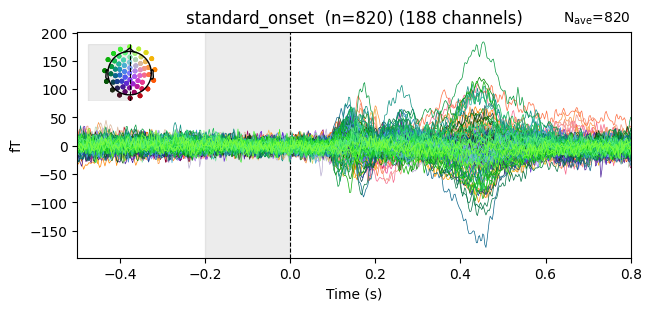

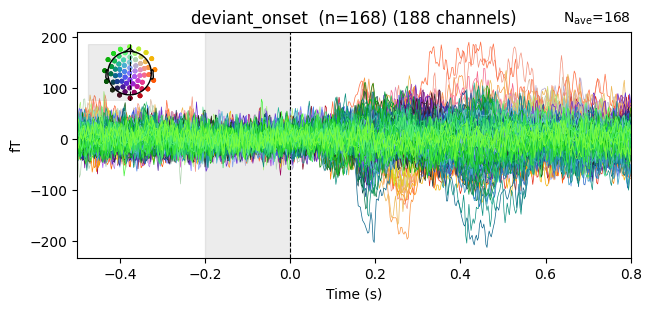

In [118]:
# Plot both conditions side-by-side for visual comparison.
# units / scalings override the default unit labels/scaling factors for display.

for evoked, label in [(evoked_std, STANDARD_COND), (evoked_dev, DEVIANT_COND)]:
    fig = evoked.plot(
        picks='mag',           # only magnetometer channels (excludes stim, eyetracking etc.)
        units=dict(mag='fT'),  # display in femtotesla instead of Tesla
        scalings=dict(mag=1e15),
        titles=dict(mag=f'{label}  (n={evoked.nave})'),
        show=False,
    )
    # evoked.plot() does not add baseline shading or an onset line automatically.
    # (Note: vlines is an epochs.plot() parameter and does not exist on evoked.plot().)
    # We add both manually across all axes in the figure.
    for ax in fig.axes:
        ax.axvline(0, color='black', lw=0.8, ls='--', zorder=3,
                   label='stimulus onset')
        ax.axvspan(-0.200, 0, color='gray', alpha=0.15, zorder=0, label='baseline')
    plt.show()


The light gray shaded region (−200 to 0 ms) marks the pre-stimulus baseline window
that was subtracted during epoching. The vertical line marks stimulus onset (t = 0).
Note that `evoked.plot()` does not add these automatically — the baseline shading is
drawn manually via `axvspan`, and the onset line is added via `axvline`.

In the deviant average you should already see a deflection in the 100–250 ms window
over temporal sensors — this is the magnetic counterpart of the MMN.

## 5. Subsetting Evoked Data

### 5a. Direct array indexing via `.data`

Because `evoked.data` is just a NumPy array, you can index it with standard NumPy
syntax to extract specific channels or time windows.

In [119]:
# Extract data for a single channel (row 0) across all time points
ch0_data = evoked_dev.data[0, :]   # shape: (n_times,)
ch0_name = evoked_dev.ch_names[0]
print(f'Channel {ch0_name}: shape={ch0_data.shape}, '
      f'peak={np.abs(ch0_data).max()*1e15:.2f} fT')

# Extract a time window directly via sample indices.
# For example, the classic MMN window: 100–250 ms post-stimulus.
# With a 400 Hz sampling rate, t=0 is at sample index 200 (0.5 s * 400 Hz),
# so 100 ms = +40 samples from t=0, and 250 ms = +100 samples from t=0.
# But we can find the indices more robustly using np.searchsorted:
t0_idx    = np.searchsorted(evoked_dev.times, 0.0)
t100_idx  = np.searchsorted(evoked_dev.times, 0.100)
t250_idx  = np.searchsorted(evoked_dev.times, 0.250)
print(f'\nt=0 ms   → sample index {t0_idx}')
print(f't=100 ms → sample index {t100_idx}')
print(f't=250 ms → sample index {t250_idx}')

# Slice of the data array: all channels in the MMN window
mmn_window_data = evoked_dev.data[:, t100_idx:t250_idx]
print(f'\nMMN window data shape: {mmn_window_data.shape}  (n_channels × n_samples)')

Channel Iz 1T Z: shape=(521,), peak=79.16 fT

t=0 ms   → sample index 200
t=100 ms → sample index 240
t=250 ms → sample index 300

MMN window data shape: (192, 60)  (n_channels × n_samples)


In [120]:
# Find which channel has the largest peak response in the MMN window.
# This kind of simple peak-picking is useful for choosing a representative sensor
# to display in figures.
peak_per_channel = np.abs(mmn_window_data).max(axis=1)   # max over time per channel
best_ch_idx  = np.argmax(peak_per_channel)
best_ch_name = evoked_dev.ch_names[best_ch_idx]
print(f'Channel with largest response in 100–250 ms window: {best_ch_name}')
print(f'  Peak amplitude: {peak_per_channel[best_ch_idx]*1e15:.2f} fT')

Channel with largest response in 100–250 ms window: P5 36 Z
  Peak amplitude: 203.35 fT


### 5b. Selecting by time: `evoked.time_as_index()`

`time_as_index()` converts one or more time values (in seconds) into the corresponding
integer sample indices, taking into account the epoch's time axis. This is the preferred
method for time-to-index conversion because it handles the epoch's `tmin` offset correctly
and is more readable than manual arithmetic.

### 🧠 Exercise A — The Auditory N100/M100

The **N100** (or **M100** in MEG) is a large response peaking around 100 ms after
auditory stimulus onset, generated by primary auditory cortex.

Because MEG sensors measure a **dipolar magnetic field**, the response appears as
both large positive and large negative deflections over temporal sensors —
two sides of the same underlying source. To find the sensors most strongly engaged,
we want a measure that captures both polarities equally. **RMS (Root Mean Square)**
is the standard choice: it is proportional to signal power, treats positive and
negative deflections symmetrically, and is the same quantity MNE uses internally
when it computes Global Field Power (GFP) across all channels.

We use the **standard** condition here (~814 trials) for the best SNR estimate of
the basic auditory onset response.

**Tasks:**
1. Use `time_as_index()` to extract the 75–150 ms window from `evoked_std`
2. Compute the RMS across time for each channel: `sqrt(mean(x²))` over that window
3. Find the top 5 channels by RMS and print their names and values
4. Plot those 5 channels on a scalp map with `plot_sensors(show_names=True)`


Top 5 channels by RMS in 75–150 ms (standard_onset):
  1. P5 36 Z               45.04 fT
  2. C5 38 Z               43.08 fT
  3. T3 3F Z               40.97 fT
  4. T5 3D Z               37.14 fT
  5. T5 3D Y               34.06 fT


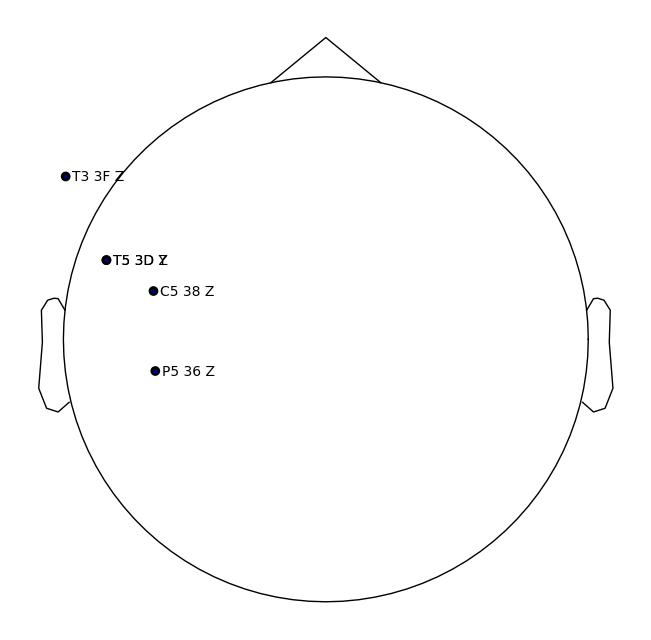

In [121]:
# ── Answer A ──────────────────────────────────────────────────────────────────

evoked_std_mag = evoked_std.copy().pick('mag', exclude='bads')

# 1. Extract the 75–150 ms window
i75  = evoked_std_mag.time_as_index(0.075)[0]
i150 = evoked_std_mag.time_as_index(0.150)[0]
window = evoked_std_mag.data[:, i75:i150]   # (n_channels, n_samples)

# 2. RMS across time for each channel: sqrt(mean(x^2))
#    This is the same quantity MNE uses for Global Field Power (GFP), applied
#    here per-channel rather than across all channels at once.
rms_per_ch = np.sqrt(np.mean(window ** 2, axis=1))

# 3. Top 5 channels by RMS
top5_idx   = np.argsort(rms_per_ch)[-5:][::-1]
top5_names = [evoked_std_mag.ch_names[i] for i in top5_idx]

print(f'Top 5 channels by RMS in 75–150 ms ({STANDARD_COND}):')
for i, (idx, name) in enumerate(zip(top5_idx, top5_names)):
    print(f'  {i+1}. {name:20s}  {rms_per_ch[idx]*1e15:.2f} fT')

# 4. Scalp map of the top 5 channels
evoked_std_mag.copy().pick_channels(top5_names).plot_sensors(
    show_names=True,
    title=f'Top 5 RMS channels — 75–150 ms ({STANDARD_COND})',
    show=False,
)
plt.show()


In [122]:
# Convert time(s) → sample index using evoked.time_as_index()
# The method accepts a scalar or a list of time values in seconds.

idx_onset    = evoked_dev.time_as_index(0.0)     # stimulus onset
idx_100ms    = evoked_dev.time_as_index(0.100)   # 100 ms post-onset
idx_250ms    = evoked_dev.time_as_index(0.250)   # 250 ms post-onset

# You can pass a list to convert multiple times at once:
indices = evoked_dev.time_as_index([0.0, 0.100, 0.150, 0.200, 0.250])

print('time_as_index results:')
for t, idx in zip([0.0, 0.100, 0.150, 0.200, 0.250], indices):
    print(f'  t = {t*1000:6.1f} ms  →  sample index {idx}  '
          f'(actual time: {evoked_dev.times[idx]*1000:.2f} ms)')

time_as_index results:
  t =    0.0 ms  →  sample index 200  (actual time: 0.00 ms)
  t =  100.0 ms  →  sample index 240  (actual time: 100.00 ms)
  t =  150.0 ms  →  sample index 260  (actual time: 150.00 ms)
  t =  200.0 ms  →  sample index 280  (actual time: 200.00 ms)
  t =  250.0 ms  →  sample index 300  (actual time: 250.00 ms)


In [123]:
# Practical use: extract the 150 ms time point for all channels
# and report which channel has the strongest amplitude at that moment.
idx_150 = evoked_dev.time_as_index(0.150)[0]   # [0] because the return is an array
amp_at_150 = evoked_dev.data[:, idx_150]        # shape: (n_channels,)

# Find extreme (signed) deflection — we want the channel with the largest absolute value
strongest_idx  = np.argmax(np.abs(amp_at_150))
strongest_name = evoked_dev.ch_names[strongest_idx]
strongest_val  = amp_at_150[strongest_idx] * 1e15  # convert to fT

print(f'At t = 150 ms, strongest channel: {strongest_name}  ({strongest_val:+.2f} fT)')

At t = 150 ms, strongest channel: T10 2I Z  (+71.58 fT)


## 6. Channel Selection

### 6a. Checking which channels are in the evoked object

When `epochs.average()` is called, MNE retains only the **primary data channels** from
the parent epochs — by default this excludes `stim`, `eyetracking`, and other auxiliary
channel types. Let's verify what we have.

In [124]:
# Get a count of each channel type present in the evoked object.
# mne.channel_type() returns the type string for one channel by index.
from collections import Counter

ch_types = Counter(
    mne.channel_type(evoked_dev.info, i)
    for i in range(evoked_dev.info['nchan'])
)
print('Channel type counts in evoked_dev:')
for ch_type, count in sorted(ch_types.items()):
    print(f'  {ch_type:20s}: {count}')

print()
# You can also check the .info directly for bad channels
print(f'Bad channels flagged: {evoked_dev.info["bads"] or "(none)"}')

Channel type counts in evoked_dev:
  mag                 : 192

Bad channels flagged: ['T14 1X Z', 'T14 1X Y', 'T14 1X X', 'F4 2N Z']


### 6b. Modifying channel selection

MNE provides several methods for selecting or excluding channels from an evoked object.
These methods modify the object **in-place** by default, so always work on a copy if
you want to preserve the original.

> **⚠️ Important: Always call `.copy()` first!**
>
> Every channel-selection method (`pick`, `pick_channels`, `pick_types`, `drop_channels`,
> `reorder_channels`) operates **in-place** — it permanently modifies the object it is called
> on, removing channels that are not selected. Once channels are dropped, they are gone
> from that object.
>
> The safest pattern is always:
> ```python
> evoked_subset = evoked_dev.copy().pick('mag', exclude='bads')
> # evoked_dev is unchanged; evoked_subset has only mag channels
> ```
> If you accidentally modify `evoked_dev` in-place, you will need to re-run the
> `epochs.average()` cell to recover it.

In [125]:
# ── pick() ────────────────────────────────────────────────────────────────────
# The most flexible method. Accepts a channel type string, a list of channel
# names, a list of indices, or a boolean mask.
# Calling pick('mag') keeps only magnetometer channels.

evoked_mag = evoked_dev.copy().pick('mag', exclude='bads')
print(f'After pick("mag"): {len(evoked_mag.ch_names)} channels')
print(f'Channel types now: {set(mne.channel_type(evoked_mag.info, i) for i in range(evoked_mag.info["nchan"]))}')

After pick("mag"): 188 channels
Channel types now: {'mag'}


In [126]:
# ── pick_channels() ───────────────────────────────────────────────────────────
# Selects channels by an explicit list of names.
# The resulting evoked will contain only the channels you name, in the order
# you specify (useful when you need a fixed, reproducible ordering).

# First, let's find some magnetometer channel names to use as examples
mag_names = [ch for ch in evoked_dev.ch_names
             if mne.channel_type(evoked_dev.info, evoked_dev.ch_names.index(ch)) == 'mag']
example_channels = mag_names[:4]   # take the first four
print(f'Example channel names: {example_channels}')

evoked_subset = evoked_dev.copy().pick_channels(example_channels)
print(f'After pick_channels(...): {evoked_subset.ch_names}')

Example channel names: ['Iz 1T Z', 'Iz 1T Y', 'Iz 1T X', 'O10 1U Z']
After pick_channels(...): ['Iz 1T Z', 'Iz 1T Y', 'Iz 1T X', 'O10 1U Z']


In [127]:
# ── pick_types() ──────────────────────────────────────────────────────────────
# Selects channels by type using keyword arguments.
# This is handy when you want to combine multiple type criteria.

# For our OPM dataset, meg=True keeps all MEG channels (synonymous with pick('mag')
# since we only have one MEG channel type).
# exclude='bads' also removes any channels flagged in info['bads'].

evoked_meg_only = evoked_dev.copy().pick_types(meg=True, exclude='bads')
print(f'After pick_types(meg=True, exclude="bads"): {len(evoked_meg_only.ch_names)} channels')

# Note: in EEG studies or mixed-modality recordings you'd use meg=False, eeg=True,
# stim=False, eog=True etc. to compose more complex selections.
# Example (not applicable here, but shown for reference):
#   evoked.copy().pick_types(meg=False, eeg=True, stim=False, eog=True)

After pick_types(meg=True, exclude="bads"): 188 channels


In [128]:
# ── drop_channels() ───────────────────────────────────────────────────────────
# Removes specific channels by name. The complement of pick_channels().
# Useful when you want to exclude just a few noisy sensors without
# needing to list all the ones you want to keep.

channels_to_drop = mag_names[:2]   # drop the first two mag channels as an example
print(f'Dropping: {channels_to_drop}')

evoked_dropped = evoked_dev.copy().drop_channels(channels_to_drop)
print(f'Before drop: {len(evoked_dev.ch_names)} channels')
print(f'After  drop: {len(evoked_dropped.ch_names)} channels')

Dropping: ['Iz 1T Z', 'Iz 1T Y']
Before drop: 192 channels
After  drop: 190 channels


In [129]:
# ── reorder_channels() ────────────────────────────────────────────────────────
# Reorders channels to match a given list of names.
# This is important when you want to align two evoked objects for arithmetic
# operations (e.g. subtraction for the MMN contrast), since MNE requires
# channel order to match.

# Create a reversed channel order as an example
reversed_names = list(reversed(mag_names[:8]))
evoked_8ch = evoked_dev.copy().pick_channels(mag_names[:8])
print(f'Original order: {evoked_8ch.ch_names}')

evoked_reordered = evoked_8ch.copy().reorder_channels(reversed_names)
print(f'Reordered     : {evoked_reordered.ch_names}')

Original order: ['Iz 1T Z', 'Iz 1T Y', 'Iz 1T X', 'O10 1U Z', 'O10 1U Y', 'O10 1U X', 'P10 1V Z', 'P10 1V Y']
Reordered     : ['P10 1V Y', 'P10 1V Z', 'O10 1U X', 'O10 1U Y', 'O10 1U Z', 'Iz 1T X', 'Iz 1T Y', 'Iz 1T Z']


## 7. Baseline Correction

Baseline correction removes any constant offset from each channel by subtracting the mean
amplitude measured during a pre-stimulus period (typically −200 to 0 ms). This:

1. **Zeroes out DC offsets** — sensors may have slow drift or a non-zero resting level
2. **Anchors the waveform** so that the pre-stimulus period averages to zero, making
   post-stimulus deflections interpretable as genuine stimulus-evoked activity
3. **Reduces low-frequency noise** that is consistent across the baseline period

In our pipeline, baseline correction was already applied during epoching
(baseline = (−0.2, 0)). Let's verify this.

In [130]:
# Check whether baseline correction has been applied.
# evoked.baseline is None if no correction was applied; otherwise it
# stores the (tmin, tmax) tuple of the baseline window that was used.

print(f'evoked_dev.baseline  : {evoked_dev.baseline}')
print(f'evoked_std.baseline  : {evoked_std.baseline}')
# Note: -0.20000000298... is floating-point representation of -0.2 s stored
# as a 32-bit float in the .fif file. It means exactly -200 ms — not an error.

# Practical check: if baseline was applied correctly, the mean signal
# over the baseline period should be close to zero for all channels.
bl_start = evoked_dev.time_as_index(-0.200)[0]
bl_end   = evoked_dev.time_as_index(0.000)[0]
bl_mean  = evoked_dev.data[:, bl_start:bl_end].mean()
print(f'\nMean across all channels in baseline window: {bl_mean:.4e} T')
# A value ~1e-17 is floating-point zero (machine epsilon).
# A real MEG signal is ~100 fT = 1e-13 T — four orders of magnitude larger.
# This confirms baseline correction was applied correctly.

evoked_dev.baseline  : (-0.20000000298023224, 0.0)
evoked_std.baseline  : (-0.20000000298023224, 0.0)

Mean across all channels in baseline window: -3.7414e-17 T


In [131]:
# How to apply baseline correction manually (or re-apply with a different window):
# evoked.apply_baseline() accepts a (tmin, tmax) tuple in seconds.
# None for either endpoint means "use the start/end of the epoch".
#
# Example: apply a standard −200 ms to 0 ms baseline
evoked_dev_bl = evoked_dev.copy().apply_baseline((-0.200, 0.0))
print(f'After apply_baseline((-0.2, 0.0)): baseline = {evoked_dev_bl.baseline}')

# Alternatively, using tmin=None extends the window to the start of the epoch:
# evoked_dev.copy().apply_baseline((None, 0.0))  # same result if tmin == epoch tmin

# For reference: if you suspect no baseline was applied (e.g. loaded from a
# raw average file), evoked.baseline will be None:
print(f'Before apply_baseline: {evoked_dev.baseline}')
print(f'After  apply_baseline: {evoked_dev_bl.baseline}')

After apply_baseline((-0.2, 0.0)): baseline = (-0.2, 0.0)
Before apply_baseline: (-0.20000000298023224, 0.0)
After  apply_baseline: (-0.2, 0.0)


## 8. Combining Evoked Objects

This section covers two distinct operations that are easy to conflate:

**Pooling trials** means going back to the epochs level and changing *which trials*
contribute to an average before calling `.average()`. For example, you might
sub-sample one condition to match another's trial count, or average across all
conditions at once. The result is a new evoked object whose `nave` reflects the
actual number of raw trials that went into it.

**Combining evoked objects** means taking two or more already-averaged objects and
mathematically combining them — adding, averaging, or subtracting them with
`mne.combine_evoked()`. No new raw trials are involved; you are operating entirely
at the averaged-response level.

We are not creating new events here. All evoked objects in this section come from
the `epochs` object we loaded in Section 1, using conditions that were already
defined at the time of epoching.


### 8a. Averaging all conditions together via a single `epochs.average()`

The simplest pooling strategy is to call `.average()` on the full epochs object
(without subsetting by condition). Each individual epoch contributes equally to the
grand average regardless of its condition label. This weights every **trial** equally.

In [132]:
# Grand average over ALL conditions — every epoch contributes one count.
# Because standards outnumber deviants ~5:1, the grand average is dominated
# by the standard response. This is useful as a summary of the "average auditory
# response" but obscures differences between conditions.

evoked_grand = epochs.average(picks='mag')
print(evoked_grand)
print(f'\nTotal epochs averaged: {evoked_grand.nave}')
print(f'  (= {len(epochs[STANDARD_COND])} standard + {len(epochs[DEVIANT_COND])} deviant)')

<Evoked | '0.17 × deviant_onset + 0.83 × standard_onset' (average, N=988), -0.5 – 0.8 s, baseline -0.2 – 0 s, 192 ch, ~18.5 MiB>

Total epochs averaged: 988
  (= 820 standard + 168 deviant)


### 8b. Equal trial counts: `equalize_event_counts()`

When comparing conditions statistically, it can be important for both conditions to
contribute the **same number of trials** to the analysis. Unequal trial counts can
bias statistical tests and produce unequal signal-to-noise ratios.

`equalize_event_counts()` randomly sub-samples the larger condition down to match
the smaller one. In our dataset standards (~814) far outnumber deviants (~166),
so this reduces the standard pool substantially.

In [133]:
# Always work on a copy — equalize_event_counts() modifies in-place.
epochs_eq = epochs.copy()

print('Before equalization:')
print(f'  {STANDARD_COND}: {len(epochs_eq[STANDARD_COND])} epochs')
print(f'  {DEVIANT_COND} : {len(epochs_eq[DEVIANT_COND])} epochs')

# equalize_event_counts() takes a list of condition labels and randomly
# drops epochs from larger conditions until all counts are equal.
# method='mintime' (default) drops epochs that are most spread out in time;
# method='truncate' simply removes the end of the longer run.
epochs_eq.equalize_event_counts([STANDARD_COND, DEVIANT_COND])

print('\nAfter equalization:')
print(f'  {STANDARD_COND}: {len(epochs_eq[STANDARD_COND])} epochs')
print(f'  {DEVIANT_COND} : {len(epochs_eq[DEVIANT_COND])} epochs')

Before equalization:
  standard_onset: 820 epochs
  deviant_onset : 168 epochs

After equalization:
  standard_onset: 168 epochs
  deviant_onset : 168 epochs


In [134]:
# Now average the equalized epochs for each condition.
# Both evoked objects will have the same nave, giving equal SNR.
evoked_std_eq = epochs_eq[STANDARD_COND].average(picks='mag')
evoked_dev_eq = epochs_eq[DEVIANT_COND].average(picks='mag')

print(f'Standard (equalized): nave = {evoked_std_eq.nave}')
print(f'Deviant  (equalized): nave = {evoked_dev_eq.nave}')

Standard (equalized): nave = 168
Deviant  (equalized): nave = 168


### 8c. Combining separately-computed evoked objects: `mne.combine_evoked()`

A third approach is to compute evoked objects for each condition independently and
then combine them using `mne.combine_evoked()`. This function can:

- **Grand-average** multiple evoked objects (weighting each evoked equally, not each trial)
- **Subtract** conditions to compute a contrast (e.g., deviant − standard = MMN)
- **Add** or **weight** arbitrarily using the `weights` parameter

The difference between `epochs.average()` on pooled data and `mne.combine_evoked()`
with equal weights is important: `combine_evoked` with `weights='equal'` weights each
**condition** equally, so standard and deviant contribute 50/50 to the output regardless
of how many trials each had. `epochs.average()` on pooled data weights each **trial**
equally, so the dominant condition (standards) contributes proportionally more.

In [135]:
# First, create mag-only evoked objects so all channel sets match
evoked_std_mag = evoked_std.copy().pick('mag', exclude='bads')
evoked_dev_mag = evoked_dev.copy().pick('mag', exclude='bads')

# ── Grand average (equal weight per condition) ──────────────────────────────
# weights='equal' divides by the number of input evoked objects (here: 0.5 + 0.5)
evoked_combined = mne.combine_evoked(
    [evoked_std_mag, evoked_dev_mag],
    weights='equal'
)
print('Grand average (condition-weighted):')
print(f'  comment : {evoked_combined.comment}')
print(f'  nave    : {evoked_combined.nave}')

Grand average (condition-weighted):
  comment : 0.500 × standard_onset + 0.500 × deviant_onset
  nave    : 557.7327935222672


MMN difference wave:
  comment : MMN (deviant − standard)


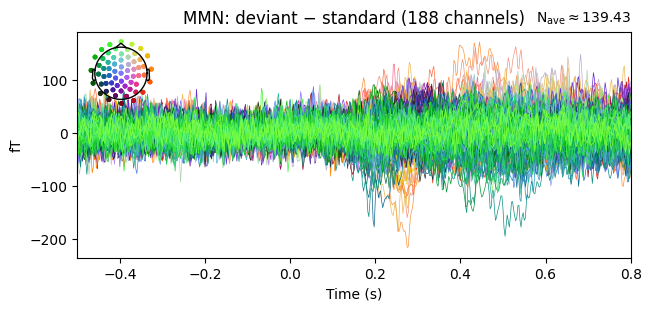

In [136]:
# ── Difference contrast: deviant − standard = MMN ──────────────────────────
# weights=[1, -1] adds the deviant waveform and subtracts the standard.
# This is the standard way to compute the MMN difference wave.
# Note: mne.combine_evoked does NOT scale by nave — it applies weights directly
# to the .data arrays. If you need a nave-weighted average, use weights='nave'.

evoked_mmn = mne.combine_evoked(
    [evoked_dev_mag, evoked_std_mag],
    weights=[1, -1]     # deviant − standard
)
evoked_mmn.comment = 'MMN (deviant − standard)'

print('MMN difference wave:')
print(f'  comment : {evoked_mmn.comment}')

fig = evoked_mmn.plot(
    units=dict(mag='fT'),
    scalings=dict(mag=1e15),
    titles=dict(mag='MMN: deviant − standard'),
    show=False,
)
plt.show()

In [137]:
# ── nave-weighted average ────────────────────────────────────────────────────
# weights='nave' weights each input evoked object by its .nave value, which
# is equivalent to the trial-weighted grand average. With unequal trial counts,
# this is dominated by the condition with more epochs (standards).

evoked_nave_weighted = mne.combine_evoked(
    [evoked_std_mag, evoked_dev_mag],
    weights='nave'
)
print('nave-weighted grand average:')
print(f'  nave    : {evoked_nave_weighted.nave}')
print(f'  (Standard nave={evoked_std_mag.nave}, Deviant nave={evoked_dev_mag.nave})')
print(f'  Combined nave should equal {evoked_std_mag.nave + evoked_dev_mag.nave}')

nave-weighted grand average:
  nave    : 988.0000000000002
  (Standard nave=820, Deviant nave=168)
  Combined nave should equal 988


### 8d. Context-matched standard: the trial immediately preceding each deviant

A subtle confound in the standard MMN contrast is **adaptation**: standards are
repeated many times, so by the time a deviant arrives, the auditory system has
been adapting to the standard tone for many repetitions. Some of the deviant–standard
difference may therefore reflect *release from adaptation* rather than genuine
prediction-error mismatch.

One way to address this is to use only the **standard trial that immediately precedes
each deviant** as the comparison baseline. That standard has experienced the same
local repetition history as the deviant it precedes, so the two averages are better
matched for adaptation state. As a bonus, the trial counts are equal by construction
— one standard per deviant — so no sub-sampling is needed.

**Important caveat:** The immediately-preceding standard is always the *last*
repetition before a context shift, which may make it slightly atypical compared to
standards drawn from the middle of a run. In practice this is a minor concern for
most paradigms, but it is worth keeping in mind. Some researchers use the *k*
trials immediately preceding each deviant (e.g. k=3) to improve SNR while still
controlling for context; here we use k=1 for simplicity.

The implementation below uses `epochs.events` directly — a NumPy array of shape
`(n_epochs, 3)` where each row is `[sample, 0, event_id]`. We iterate over that
array to find the index of each deviant trial, then look one step back to find its
preceding standard.

Deviants found          : 168
Preceding standards found: 168

evoked_std_matched nave : 168
evoked_dev nave         : 168
Trial counts match      : True


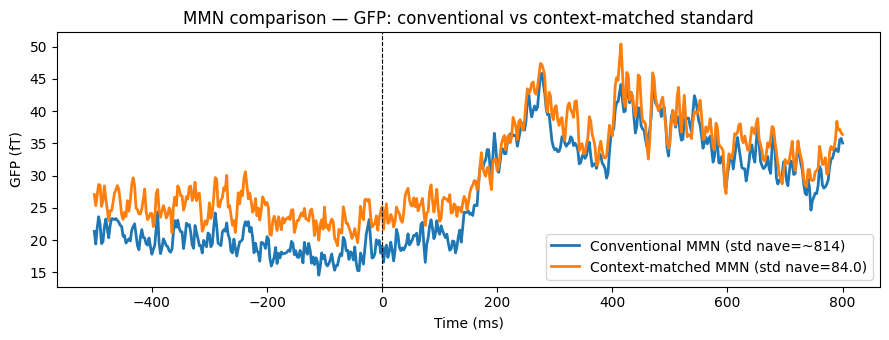

In [138]:
# ── 8d. Average of standards immediately preceding each deviant ───────────────

# epochs.events is a (n_epochs, 3) array: [sample_onset, 0, event_id]
# epochs.event_id is a dict mapping condition name → integer event ID
std_id = epochs.event_id[STANDARD_COND]
dev_id = epochs.event_id[DEVIANT_COND]

events     = epochs.events          # (n_epochs, 3)
event_ids  = events[:, 2]           # just the event-ID column

# Walk through the event list and collect the epoch index of each standard
# that directly precedes a deviant.
preceding_std_indices = []

for i, ev_id in enumerate(event_ids):
    if ev_id == dev_id and i > 0:           # found a deviant that isn't the first epoch
        if event_ids[i - 1] == std_id:      # the epoch immediately before it is a standard
            preceding_std_indices.append(i - 1)

print(f'Deviants found          : {(event_ids == dev_id).sum()}')
print(f'Preceding standards found: {len(preceding_std_indices)}')

# Use integer indexing to select only those epoch rows, then average.
# epochs[list_of_ints] selects by position, not by condition label.
evoked_std_matched = (
    epochs[preceding_std_indices]
    .average(picks='mag')
)
evoked_std_matched.comment = f'{STANDARD_COND} (preceding-deviant matched)'

print(f'\nevoked_std_matched nave : {evoked_std_matched.nave}')
print(f'evoked_dev nave         : {evoked_dev.nave}')
print(f'Trial counts match      : {evoked_std_matched.nave == evoked_dev.nave}')

# Compute the context-matched MMN difference wave
evoked_mmn_matched = mne.combine_evoked(
    [evoked_dev.copy().pick('mag', exclude='bads'),
     evoked_std_matched.copy().pick('mag', exclude='bads')],
    weights=[1, -1],
)
evoked_mmn_matched.comment = 'MMN context-matched (deviant - preceding standard)'

# Equalized MMN: deviant − standard using equal trial counts from 8b.
# This controls for trial-count imbalance but draws the standard trials
# randomly rather than by their position relative to deviants.
evoked_mmn_eq = mne.combine_evoked(
    [evoked_dev_eq.copy().pick('mag', exclude='bads'),
     evoked_std_eq.copy().pick('mag', exclude='bads')],
    weights=[1, -1],
)
evoked_mmn_eq.comment = 'MMN equalized (deviant - standard, equal nave)'

# Two-way comparison:
#   Conventional    — all ~814 standards, best SNR on the standard side
#   Context-matched — only the ~168 standards preceding each deviant
# The conventional MMN has higher SNR on the standard average but is more
# susceptible to adaptation confounds. If the two curves look similar,
# adaptation is unlikely to be driving the effect. If the context-matched
# MMN is smaller, the conventional estimate may be inflated by adaptation.

# Pick mag channels consistently for both difference waves
mmn_conv_mag    = evoked_mmn.copy().pick('mag', exclude='bads')
mmn_matched_mag = evoked_mmn_matched.copy().pick('mag', exclude='bads')

# Compute GFP (RMS across channels) for each time point
gfp_conv    = np.sqrt(np.mean(mmn_conv_mag.data    ** 2, axis=0)) * 1e15
gfp_matched = np.sqrt(np.mean(mmn_matched_mag.data ** 2, axis=0)) * 1e15
t_ms        = mmn_conv_mag.times * 1000

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_ms, gfp_conv,    color='tab:blue',   lw=2, label=f'Conventional MMN (std nave=~814)')
ax.plot(t_ms, gfp_matched, color='tab:orange', lw=2, label=f'Context-matched MMN (std nave={mmn_matched_mag.nave})')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.axvspan(-0.200, 0, color='gray', alpha=0.15)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('GFP (fT)')
ax.set_title('MMN comparison — GFP: conventional vs context-matched standard')
ax.legend()
plt.tight_layout()
plt.show()

# ── What to look for ─────────────────────────────────────────────────────────
# A common pattern is for the context-matched GFP to be *higher* than the
# conventional GFP in early time windows (<~180 ms), then for the two curves
# to converge in the later MMN window.
#
# Early window (context-matched > conventional):
# Two explanations are possible and may both contribute:
#
#   1. SNR difference. The conventional standard average uses ~5x more trials,
#      so its noise averages down much more. The context-matched standard average
#      (~168 trials) is noisier, and that noise carries into the difference wave,
#      inflating GFP in windows where the true signal is relatively small.
#      GFP has a noise floor that scales with 1/sqrt(nave), so fewer trials
#      means a higher baseline even when nothing meaningful is happening.
#
#   2. Genuine adaptation effect. The immediately-preceding standard is the
#      *least* adapted trial in the run — the auditory system has not yet fully
#      suppressed it. Subtracting a less-adapted standard from the deviant
#      leaves more residual early response in the difference wave.
#
# Late window (curves converge after ~180 ms):
# The MMN signal is large enough by this point to dominate both curves
# regardless of which standards were used. The noise floor differences
# become negligible relative to the genuine mismatch response.
#
# Practical implication:
# In this dataset the conventional MMN is probably the more reliable estimate
# of the true effect, simply because of the SNR advantage. Context-matching
# is a principled approach but needs more deviant trials to be competitive.
# With ~500+ deviants the two curves would likely converge across the full
# time window, making the adaptation control meaningful rather than
# noise-limited.


## 9. Standard Error and the `kind` Attribute

Beyond the average waveform, it is often useful to quantify **trial-by-trial variability**.
`epochs.standard_error()` computes the standard error of the mean (SEM) across trials,
using the same averaging pathway as `.average()`.

The resulting object has `evoked.kind == 'standard_error'` rather than `'average'`,
which MNE uses internally to apply different plotting logic (e.g., shading ± SEM).

In [139]:
# Compute the standard error of the mean across deviant trials.
# Internally: SEM = std(data, axis=0) / sqrt(nave)
evoked_dev_se = epochs[DEVIANT_COND].standard_error(picks='mag')

print(f'kind  : {evoked_dev_se.kind}')        # 'standard_error'
print(f'nave  : {evoked_dev_se.nave}')         # same as evoked_dev.nave
print(f'shape : {evoked_dev_se.data.shape}')   # same shape as the average

print()
# Compare with the average
print(f'Average kind     : {evoked_dev.kind}')
print(f'Std. error kind  : {evoked_dev_se.kind}')

kind  : standard_error
nave  : 168
shape : (192, 521)

Average kind     : average
Std. error kind  : standard_error


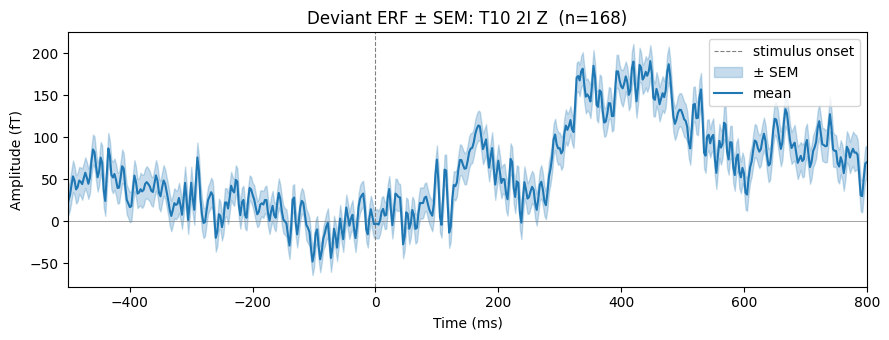

In [140]:
# We can manually overlay ± SEM as a shaded band on a plot for one channel.
# This illustrates the relationship between the average and the SEM objects.

evoked_dev_mag = evoked_dev.copy().pick('mag', exclude='bads')
evoked_dev_se_mag = evoked_dev_se.copy()

# Pick the channel with the largest deviant response for the plot
best_idx = int(np.argmax(np.abs(evoked_dev_mag.data[:, evoked_dev_mag.time_as_index(0.150)[0]]))
)
ch_name = evoked_dev_mag.ch_names[best_idx]

avg_trace = evoked_dev_mag.data[best_idx, :]   * 1e15   # fT
sem_trace = evoked_dev_se_mag.data[best_idx, :] * 1e15  # fT
t         = evoked_dev_mag.times * 1000                  # ms

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axvline(0, color='gray', lw=0.8, ls='--', label='stimulus onset')
ax.axhline(0, color='gray', lw=0.5)
ax.fill_between(t, avg_trace - sem_trace, avg_trace + sem_trace,
                alpha=0.25, color='tab:blue', label='± SEM')
ax.plot(t, avg_trace, color='tab:blue', lw=1.5, label='mean')
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Amplitude (fT)')
ax.set_title(f'Deviant ERF ± SEM: {ch_name}  (n={evoked_dev_mag.nave})')
ax.legend(loc='upper right')
ax.set_xlim(t[0], t[-1])
plt.tight_layout()
plt.show()

## 11. Saving and Loading Evoked Objects

Evoked objects can be saved to `.fif` files using `evoked.save()` and reloaded with
`mne.read_evokeds()`. Note that unlike epochs, a single `.fif` file can store
**multiple** evoked objects (e.g., both conditions, plus the difference wave).
`mne.read_evokeds()` returns a **list** of evoked objects.

In [141]:
# Save both conditions, all MMN variants, and the context-matched standard
# to a single .fif file.
# By convention, evoked files end in -ave.fif (the pipeline also uses _ave.fif).

evoked_fif = DERIV_DIR / f'{SUBJECT}_{SESSION}_task-{TASK}_ave.fif'

# Ensure comment strings use plain ASCII hyphens (no Unicode minus U+2212)
evoked_mmn.comment         = 'MMN (deviant - standard)'
evoked_mmn_matched.comment = 'MMN context-matched (deviant - preceding standard)'
evoked_std_matched.comment = 'standard_onset (preceding-deviant matched)'

import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    mne.write_evokeds(
        evoked_fif,
        [evoked_std_mag, evoked_dev_mag, evoked_mmn,
         evoked_mmn_matched, evoked_std_matched],
        overwrite=True
    )
print(f'Saved: {evoked_fif}')

evokeds_loaded = mne.read_evokeds(evoked_fif, verbose=False)
print(f'\nLoaded {len(evokeds_loaded)} evoked objects:')
for evo in evokeds_loaded:
    print(f'  comment="{evo.comment}"  nave={evo.nave}  kind={evo.kind}')


Saved: /Users/markpinsk/opm-projects/oddball/data/oddball/bids/derivatives/analysis1__/sub-001/ses-01/meg/sub-001_ses-01_task-oddball_ave.fif

Loaded 4 evoked objects:
  comment="standard_onset"  nave=820  kind=average
  comment="deviant_onset"  nave=168  kind=average
  comment="MMN (deviant - standard)"  nave=139  kind=average
  comment="MMN context-matched (deviant - preceding standard)"  nave=84  kind=average


In [142]:
# You can also load a specific condition by name using the 'condition' argument,
# which avoids loading all objects when you only need one.
evo_mmn_reload = mne.read_evokeds(
    evoked_fif,
    condition='MMN (deviant - standard)',
    verbose=False
)
print(f'Loaded by name: "{evo_mmn_reload.comment}"  nave={evo_mmn_reload.nave}')

Loaded by name: "MMN (deviant - standard)"  nave=139


## 12. Summary

This notebook covered the core structure and manipulation of `Evoked` objects in MNE.
Here's a quick reference:

| Task | Method / Attribute |
|------|--------------------|
| Create from epochs | `epochs[cond].average()` |
| Create std. error | `epochs[cond].standard_error()` |
| Number of trials | `evoked.nave` |
| Condition label | `evoked.comment` |
| Average vs. SE | `evoked.kind` |
| Time axis | `evoked.times`, `evoked.tmin`, `evoked.tmax` |
| Raw data array | `evoked.data` (shape: channels × times) |
| Time → sample index | `evoked.time_as_index(t_sec)` |
| Select by type | `evoked.copy().pick('mag')` |
| Select by name | `evoked.copy().pick_channels([...])` |
| Type-based selection | `evoked.copy().pick_types(meg=True)` |
| Remove channels | `evoked.copy().drop_channels([...])` |
| Reorder channels | `evoked.copy().reorder_channels([...])` |
| Baseline correction | `evoked.apply_baseline((tmin, tmax))` |
| Check baseline | `evoked.baseline` |
| Combine/contrast | `mne.combine_evoked([...], weights=[1,-1])` |
| Single-trial Evokeds | `evoked.iter_evoked()` | Yields one `nave=1` Evoked per epoch; useful for per-trial inspection |
| Equalize trial counts | `epochs.copy().equalize_event_counts([...])` |
| Iterate single trials | `epochs.iter_evoked()` |
| Save | `mne.write_evokeds(fname, [evo1, evo2])` |
| Load | `mne.read_evokeds(fname)` |

### What to expect in this dataset
### Next steps

After running the cells in this notebook you should have:

- Two condition averages: `evoked_std` (≈814 trials) and `evoked_dev` (≈168 trials)
- A **context-matched MMN** (`evoked_mmn_matched`) as the primary difference wave
  going forward — deviant minus the standard immediately preceding each deviant,
  giving equal trial counts (~168 per condition) and better adaptation control
  than the conventional contrast
- An early auditory response (N100/M100) peaking around **100 ms** post-onset,
  visible as a large deflection over temporal sensors in both condition averages
- A context-matched MMN difference wave with a visible deflection peaking somewhere
  between **200–300 ms** post-onset
- A reminder of how the MMN looks different in EEG vs OPM-MEG: in EEG it is a
  frontocentral negative voltage (maximal at Fz); in OPM-MEG it is a **dipolar
  magnetic field pattern** — opposing positive and negative clusters over bilateral
  temporal sensors, reflecting the physics of magnetic dipoles rather than neural
  polarity

### Next steps
- **Visualizing Evoked data** — `evoked.plot_topomap()`, `evoked.plot_joint()`, global field power (GFP)
- **ERP/ERF analysis** — peak detection, mean amplitude in time windows, condition contrasts
